## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.87MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.32MB/s]


torch.Size([28, 28])


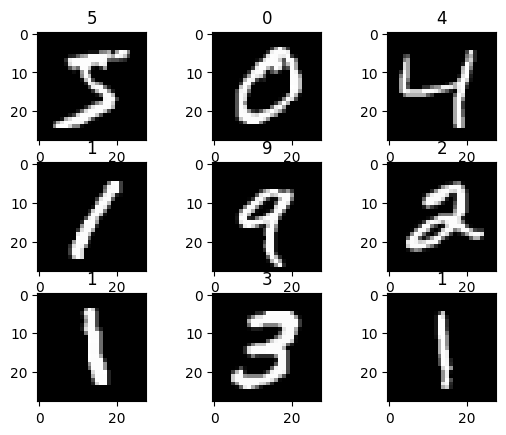

In [4]:
# 데이터셋 정의 -> MNIST
transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_data = datasets.MNIST(
    root='./data/',
    train=True,
    download=True,
    transform = transform)



test_data = datasets.MNIST(
    root="../data/",
    train=False,
    download=True,
    transform=transforms.ToTensor())

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i], cmap="gray")
    plt.title(train_data.targets[i].item())

print(train_data.data[0].shape)
plt.show()

In [5]:
from torch.utils.data import Dataset

class CustomMNIST(Dataset):
    def __init__(self, root, train=True, download=False):

        self.base_dataset = datasets.MNIST(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, label

# 인스턴스 생성
train_data = CustomMNIST(root='./data/', train=True, download=True)
test_data = CustomMNIST(root='./data/', train=False, download=True)

## Modeling

In [6]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.2)

        # initialization
        nn.init.kaiming_normal_(self.conv1.weight)
        nn.init.kaiming_normal_(self.conv2.weight)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.pool(x)
        x = self.dropout(x)

        return x

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()

        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(256*3*3, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [9]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cpu


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (

In [10]:
# Learning rate
lr = 1e-3

# Optimizer
optim = Adam(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

# Train loop
for epoch in range(100):
    model.train()

    for data, label in tqdm(train_loader): # read data
        data = data.to(device)
        label = label.to(device)

        optim.zero_grad() # Iniitlaization

        preds = model(data) # prediction

        # Loss Function
        loss = criterion(preds, label)

        loss.backward()
        optim.step()

    if epoch==0 or epoch%10==9: # 10번마다 손실 출력
        print(f"epoch{epoch+1} loss:{loss.item()}")

# 모델 저장
torch.save(model.state_dict(), "MNIST_CNN.pth")

100%|██████████| 938/938 [08:37<00:00,  1.81it/s]


epoch1 loss:0.06043711677193642


100%|██████████| 938/938 [08:40<00:00,  1.80it/s]


epoch10 loss:0.02858945168554783


 15%|█▌        | 144/938 [01:21<07:28,  1.77it/s]


KeyboardInterrupt: 

In [11]:
model.load_state_dict(torch.load("MNIST_CNN.pth", map_location=device))
model.eval()

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        data = data.to(device)
        label = label.to(device)

        output = model(data)
        preds = output.argmax(dim=1)

        corr = preds.eq(label).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

FileNotFoundError: [Errno 2] No such file or directory: 'MNIST_CNN.pth'